In [1]:
# Check GPU is available
import torch
print(torch.__version__)
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

2.10.0+cu128
GPU available: True
Device: Tesla T4


In [2]:
# Install kaggle
!pip install kaggle -q
print("Done!")

Done!


In [1]:
import os
os.environ['KAGGLE_USERNAME'] = "divyabashyal56"
os.environ['KAGGLE_KEY'] = "KGAT_c7ee1a4e0d244f3dea773a6ce29d96ba"

In [2]:
!mkdir -p ~/.kaggle
!echo '{"username":"divyabashyal56","key":"KGAT_c7ee1a4e0d244f3dea773a6ce29d96ba"}' > ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
print("Kaggle setup done!")

Kaggle setup done!


In [3]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -q
print("Download done!")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
Download done!


In [4]:
!unzip -q chest-xray-pneumonia.zip
!ls chest_xray/
print("Unzip done!")


chest_xray  __MACOSX  test  train  val
Unzip done!


In [5]:
!pip install scikit-learn matplotlib -q
print("Done!")

Done!


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

Using: cuda


In [7]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
print("Transforms ready!")

Transforms ready!


In [8]:
train_dataset = datasets.ImageFolder('chest_xray/train', transform=train_transforms)
val_dataset   = datasets.ImageFolder('chest_xray/val',   transform=val_transforms)
test_dataset  = datasets.ImageFolder('chest_xray/test',  transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print(f"Classes: {train_dataset.classes}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes: ['NORMAL', 'PNEUMONIA']
Train: 5216 | Val: 16 | Test: 624


In [9]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

model.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(model.fc.in_features, 2)
)

model = model.to(device)
print("Model ready!")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 126MB/s]


Model ready!
Trainable params: 8,394,754


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
print("Optimizer ready!")

Optimizer ready!


In [11]:
def train_model(model, train_loader, val_loader, epochs=15):
    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []
    best_val_acc = 0.0

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total   += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc  = 100. * correct / total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss    += loss.item()
                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total   += labels.size(0)

        val_loss = val_loss / len(val_loader)
        val_acc  = 100. * val_correct / val_total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"Best model saved (val_acc: {val_acc:.2f}%)")

        scheduler.step()

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%")

    return train_losses, val_losses, train_accs, val_accs

print("Training function ready!")

Training function ready!


In [12]:
train_losses, val_losses, train_accs, val_accs = train_model(
    model, train_loader, val_loader, epochs=10
)
print("Training complete!")

Best model saved (val_acc: 87.50%)
Epoch [1/10] Train Loss: 0.1351 Acc: 94.59% | Val Loss: 0.2145 Acc: 87.50%
Best model saved (val_acc: 93.75%)
Epoch [2/10] Train Loss: 0.0740 Acc: 97.01% | Val Loss: 0.2010 Acc: 93.75%
Epoch [3/10] Train Loss: 0.0656 Acc: 97.55% | Val Loss: 1.2235 Acc: 56.25%
Epoch [4/10] Train Loss: 0.0459 Acc: 98.43% | Val Loss: 0.1755 Acc: 87.50%
Epoch [5/10] Train Loss: 0.0385 Acc: 98.66% | Val Loss: 0.3887 Acc: 75.00%
Epoch [6/10] Train Loss: 0.0276 Acc: 99.00% | Val Loss: 0.3826 Acc: 81.25%
Epoch [7/10] Train Loss: 0.0276 Acc: 99.06% | Val Loss: 0.4296 Acc: 75.00%
Epoch [8/10] Train Loss: 0.0258 Acc: 99.08% | Val Loss: 0.5128 Acc: 75.00%
Epoch [9/10] Train Loss: 0.0257 Acc: 99.14% | Val Loss: 0.3637 Acc: 81.25%
Epoch [10/10] Train Loss: 0.0239 Acc: 99.23% | Val Loss: 0.3877 Acc: 81.25%
Training complete!


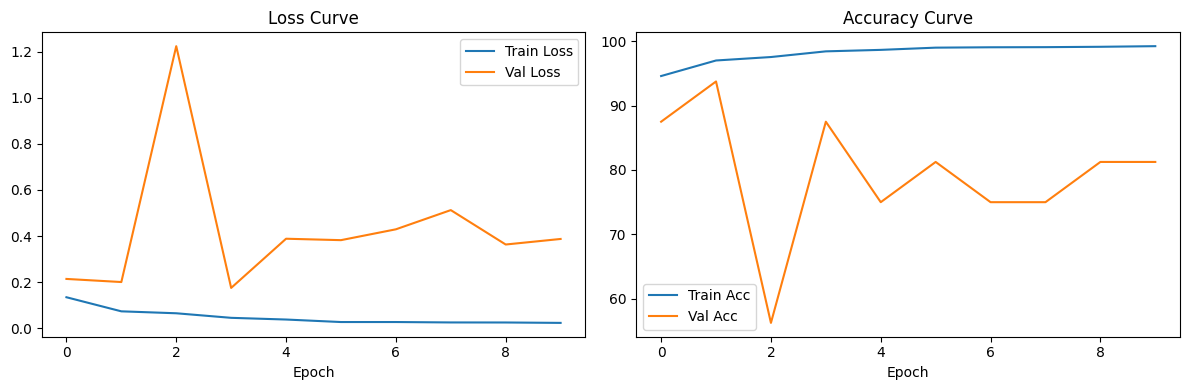

Plots saved!


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses,   label='Val Loss')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(train_accs, label='Train Acc')
ax2.plot(val_accs,   label='Val Acc')
ax2.set_title('Accuracy Curve')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()
print("Plots saved!")

In [14]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print("── Test Results ──────────────────────────")
print(classification_report(all_labels, all_preds,
                             target_names=train_dataset.classes))

── Test Results ──────────────────────────
              precision    recall  f1-score   support

      NORMAL       0.97      0.62      0.76       234
   PNEUMONIA       0.81      0.99      0.89       390

    accuracy                           0.85       624
   macro avg       0.89      0.81      0.83       624
weighted avg       0.87      0.85      0.84       624



In [15]:
from google.colab import files
files.download('best_model.pth')
files.download('training_curves.png')
print("Downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded!
